In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig

# Read the CSV file
df = pd.read_csv('../data/w_ij_gaa.csv')

# Get node names from first column and column headers
source_nodes = df.iloc[:, 0].values
target_nodes = df.columns[1:].values

print(f"Number of source nodes: {len(source_nodes)}")
print(f"Number of target nodes: {len(target_nodes)}")

# Create edge list with weights
edges = []
weights = []
edge_list_data = []

for i, source in enumerate(source_nodes):
    for j, target in enumerate(target_nodes):
        weight = df.iloc[i, j+1]
        if not pd.isna(weight) and weight != 0:  # Only include non-zero connections
            edges.append((source, target))
            weights.append(weight)
            edge_list_data.append({
                'source': source,
                'target': target,
                'weight': weight
            })

print(f"\nTotal non-zero connections: {len(edges)}")

Number of source nodes: 72
Number of target nodes: 72

Total non-zero connections: 1151


In [2]:
# Create igraph Graph
g = ig.Graph()

# Add all unique nodes
all_nodes = list(set(list(source_nodes) + list(target_nodes)))
g.add_vertices(all_nodes)

# Add edges with weights
g.add_edges(edges)
g.es['weight'] = weights

print(f"\nGraph summary:")
print(f"  Nodes: {g.vcount()}")
print(f"  Edges: {g.ecount()}")
print(f"  Density: {g.density():.6f}")

# Calculate network statistics
print(f"\nNetwork statistics:")
print(f"  Average degree: {np.mean(g.degree()):.2f}")
print(f"  Max degree: {max(g.degree())}")
print(f"  Min degree: {min(g.degree())}")

# Get weight statistics
weights_array = np.array(weights)
print(f"\nWeight statistics:")
print(f"  Mean: {np.mean(weights_array):.6f}")
print(f"  Median: {np.median(weights_array):.6f}")
print(f"  Std Dev: {np.std(weights_array):.6f}")
print(f"  Min: {np.min(weights_array):.6f}")
print(f"  Max: {np.max(weights_array):.6f}")


Graph summary:
  Nodes: 72
  Edges: 1151
  Density: 0.450313

Network statistics:
  Average degree: 31.97
  Max degree: 59
  Min degree: 10

Weight statistics:
  Mean: 63598.641954
  Median: -13.412772
  Std Dev: 271296.470665
  Min: -31424.092440
  Max: 2982732.151000



Network analysis figure saved to network_analysis.png

Saving graph files...
  - GraphML format: network.graphml
  - Edge list CSV: edge_list.csv
  - Adjacency list: adjacency_list.txt


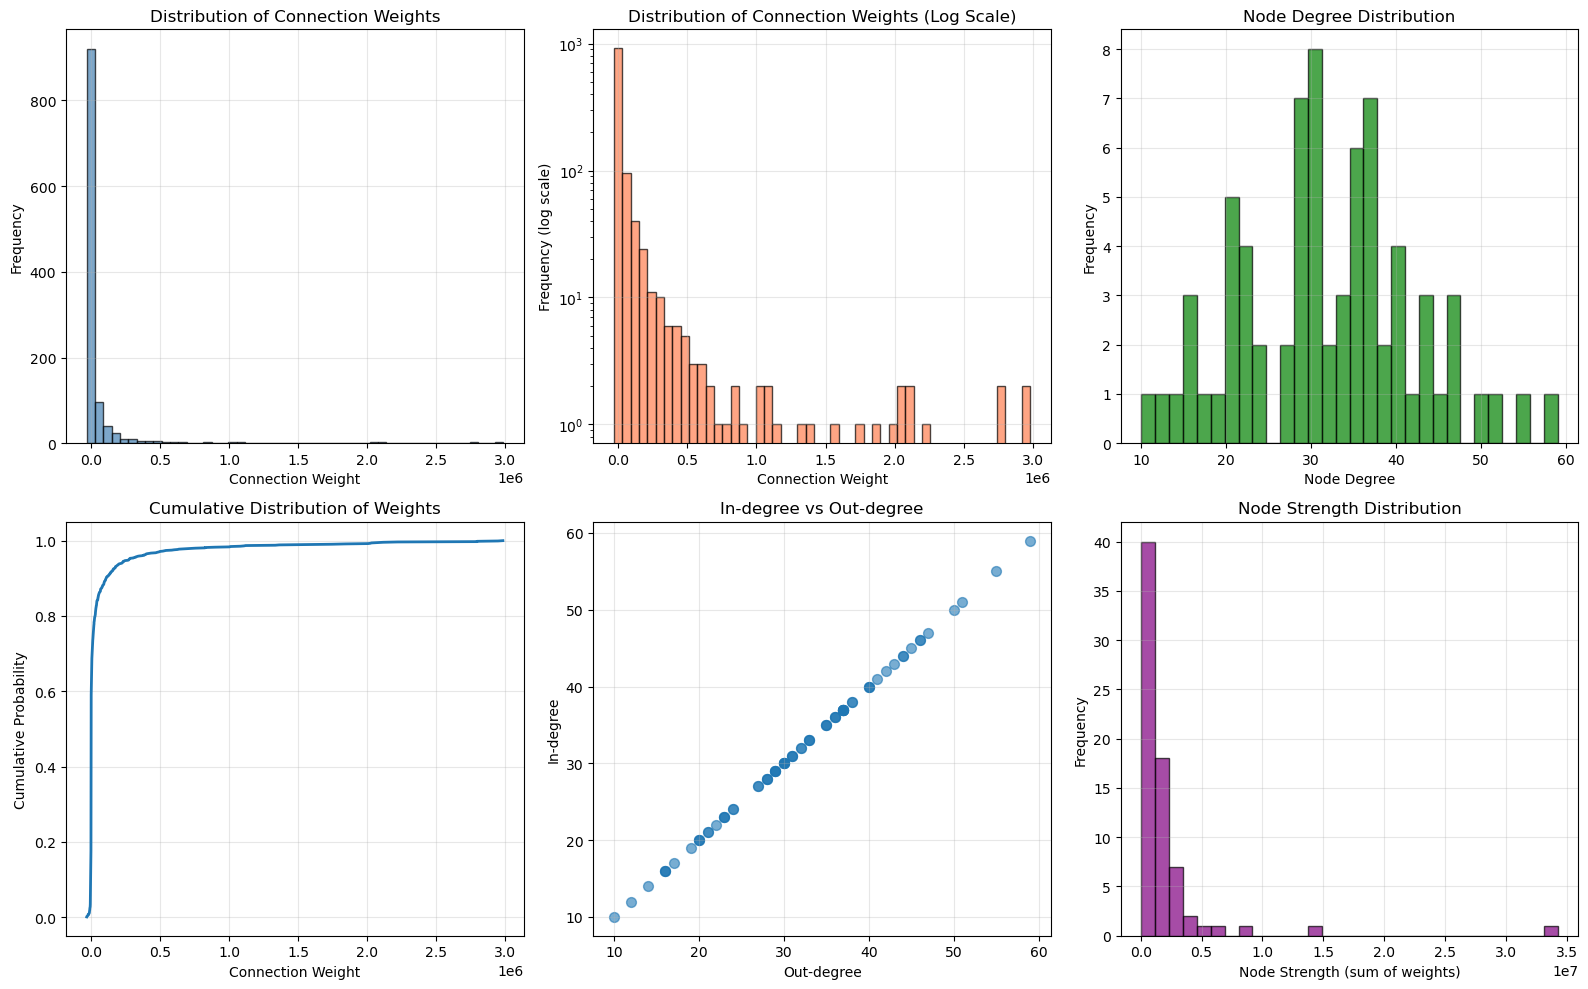

In [3]:
# Create visualizations
fig = plt.figure(figsize=(16, 10))

# Subplot 1: Weight histogram (linear scale)
ax1 = plt.subplot(2, 3, 1)
ax1.hist(weights_array, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Connection Weight')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Connection Weights')
ax1.grid(True, alpha=0.3)

# Subplot 2: Weight histogram (log scale)
ax2 = plt.subplot(2, 3, 2)
ax2.hist(weights_array, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Connection Weight')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_title('Distribution of Connection Weights (Log Scale)')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Subplot 3: Degree distribution
ax3 = plt.subplot(2, 3, 3)
degrees = g.degree()
ax3.hist(degrees, bins=30, edgecolor='black', alpha=0.7, color='green')
ax3.set_xlabel('Node Degree')
ax3.set_ylabel('Frequency')
ax3.set_title('Node Degree Distribution')
ax3.grid(True, alpha=0.3)

# Subplot 4: Cumulative weight distribution
ax4 = plt.subplot(2, 3, 4)
sorted_weights = np.sort(weights_array)
cumulative = np.arange(1, len(sorted_weights) + 1) / len(sorted_weights)
ax4.plot(sorted_weights, cumulative, linewidth=2)
ax4.set_xlabel('Connection Weight')
ax4.set_ylabel('Cumulative Probability')
ax4.set_title('Cumulative Distribution of Weights')
ax4.grid(True, alpha=0.3)

# Subplot 5: In-degree vs Out-degree
ax5 = plt.subplot(2, 3, 5)
in_degrees = g.degree(mode='in')
out_degrees = g.degree(mode='out')
ax5.scatter(out_degrees, in_degrees, alpha=0.6, s=50)
ax5.set_xlabel('Out-degree')
ax5.set_ylabel('In-degree')
ax5.set_title('In-degree vs Out-degree')
ax5.grid(True, alpha=0.3)

# Subplot 6: Weight strength distribution
ax6 = plt.subplot(2, 3, 6)
strengths = g.strength(weights='weight')
ax6.hist(strengths, bins=30, edgecolor='black', alpha=0.7, color='purple')
ax6.set_xlabel('Node Strength (sum of weights)')
ax6.set_ylabel('Frequency')
ax6.set_title('Node Strength Distribution')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/netlist/network_analysis.png', dpi=300, bbox_inches='tight')
print("\nNetwork analysis figure saved to network_analysis.png")

# Save the graph in multiple formats
print("\nSaving graph files...")

# Save as GraphML (preserves attributes)
g.write_graphml('../outputs/netlist/network.graphml')
print("  - GraphML format: network.graphml")

# Save edge list as CSV
edge_df = pd.DataFrame(edge_list_data)
edge_df.to_csv('../outputs/netlist/edge_list.csv', index=False)
print("  - Edge list CSV: edge_list.csv")

# Save as adjacency list
with open('../outputs/netlist/adjacency_list.txt', 'w') as f:
    for v in g.vs:
        neighbors = g.neighbors(v.index, mode='out')
        if neighbors:
            neighbor_names = [g.vs[n]['name'] for n in neighbors]
            neighbor_weights = [g.es[g.get_eid(v.index, n)]['weight'] for n in neighbors]
            f.write(f"{v['name']}: ")
            f.write(", ".join([f"{name}({weight:.6f})" for name, weight in zip(neighbor_names, neighbor_weights)]))
            f.write("\n")
print("  - Adjacency list: adjacency_list.txt")

In [4]:
# Create detailed netlist
with open('../outputs/netlist/netlist.txt', 'w') as f:
    f.write("# Neural Network Connectivity Netlist\n")
    f.write(f"# Generated from igraph analysis\n")
    f.write(f"# Total nodes: {g.vcount()}\n")
    f.write(f"# Total edges: {g.ecount()}\n")
    f.write(f"# Weight range: [{np.min(weights_array):.6f}, {np.max(weights_array):.6f}]\n")
    f.write("#\n")
    f.write("# Format: source_node -> target_node [weight]\n")
    f.write("#" + "="*60 + "\n\n")
    
    for edge in g.es:
        source = g.vs[edge.source]['name']
        target = g.vs[edge.target]['name']
        weight = edge['weight']
        f.write(f"{source} -> {target} [{weight:.6f}]\n")

print("  - Netlist: netlist.txt")

  - Netlist: netlist.txt


In [5]:
# Create comprehensive statistics file
with open('../outputs/netlist/network_statistics.txt', 'w') as f:
    f.write("Neural Network Connectivity Statistics\n")
    f.write("="*60 + "\n\n")
    
    f.write("GRAPH PROPERTIES\n")
    f.write("-"*60 + "\n")
    f.write(f"Number of nodes: {g.vcount()}\n")
    f.write(f"Number of edges: {g.ecount()}\n")
    f.write(f"Graph density: {g.density():.6f}\n")
    f.write(f"Is directed: {g.is_directed()}\n\n")
    
    f.write("DEGREE STATISTICS\n")
    f.write("-"*60 + "\n")
    degrees = g.degree()
    f.write(f"Average degree: {np.mean(degrees):.2f}\n")
    f.write(f"Median degree: {np.median(degrees):.2f}\n")
    f.write(f"Max degree: {max(degrees)}\n")
    f.write(f"Min degree: {min(degrees)}\n\n")
    
    f.write("WEIGHT STATISTICS\n")
    f.write("-"*60 + "\n")
    f.write(f"Total connections: {len(weights_array)}\n")
    f.write(f"Mean weight: {np.mean(weights_array):.6f}\n")
    f.write(f"Median weight: {np.median(weights_array):.6f}\n")
    f.write(f"Standard deviation: {np.std(weights_array):.6f}\n")
    f.write(f"Min weight: {np.min(weights_array):.6f}\n")
    f.write(f"Max weight: {np.max(weights_array):.6f}\n\n")
    
    f.write("WEIGHT PERCENTILES\n")
    f.write("-"*60 + "\n")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        f.write(f"{p:3d}th percentile: {np.percentile(weights_array, p):.6f}\n")
    
    f.write("\n")
    f.write("NODE STRENGTH STATISTICS\n")
    f.write("-"*60 + "\n")
    strengths = g.strength(weights='weight')
    f.write(f"Average strength: {np.mean(strengths):.6f}\n")
    f.write(f"Median strength: {np.median(strengths):.6f}\n")
    f.write(f"Max strength: {np.max(strengths):.6f}\n")
    f.write(f"Min strength: {np.min(strengths):.6f}\n\n")
    
    f.write("TOP 10 NODES BY STRENGTH\n")
    f.write("-"*60 + "\n")
    strength_order = np.argsort(strengths)[::-1]
    for i, idx in enumerate(strength_order[:10], 1):
        f.write(f"{i:2d}. {g.vs[idx]['name']:40s} {strengths[idx]:.6f}\n")

print("  - Statistics: network_statistics.txt")

  - Statistics: network_statistics.txt


In [6]:
# Save node statistics as CSV
node_stats = pd.DataFrame({
    'node_name': [v['name'] for v in g.vs],
    'degree': g.degree(),
    'in_degree': g.degree(mode='in'),
    'out_degree': g.degree(mode='out'),
    'strength': g.strength(weights='weight'),
    'in_strength': g.strength(mode='in', weights='weight'),
    'out_strength': g.strength(mode='out', weights='weight')
})
node_stats.to_csv('../outputs/netlist/node_statistics.csv', index=False)
print("  - Node statistics CSV: node_statistics.csv")

# Save weight statistics as CSV
weight_stats_df = pd.DataFrame({
    'weight': weights_array
})
weight_stats_df.to_csv('../outputs/netlist/weights.csv', index=False)
print("  - All weights CSV: weights.csv")

  - Node statistics CSV: node_statistics.csv
  - All weights CSV: weights.csv


In [7]:
# Save summary statistics as CSV
summary_stats = pd.DataFrame({
    'metric': [
        'num_nodes', 'num_edges', 'density', 
        'avg_degree', 'median_degree', 'max_degree', 'min_degree',
        'avg_weight', 'median_weight', 'std_weight', 'min_weight', 'max_weight',
        'avg_strength', 'median_strength', 'max_strength', 'min_strength'
    ],
    'value': [
        g.vcount(), g.ecount(), g.density(),
        np.mean(degrees), np.median(degrees), max(degrees), min(degrees),
        np.mean(weights_array), np.median(weights_array), np.std(weights_array), 
        np.min(weights_array), np.max(weights_array),
        np.mean(strengths), np.median(strengths), np.max(strengths), np.min(strengths)
    ]
})
summary_stats.to_csv('../outputs/netlist/summary_statistics.csv', index=False)
print("  - Summary statistics CSV: summary_statistics.csv")

  - Summary statistics CSV: summary_statistics.csv


In [8]:
# Create comprehensive statistics file
with open('../outputs/network_statistics.txt', 'w') as f:
    f.write("Neural Network Connectivity Statistics\n")
    f.write("="*60 + "\n\n")
    
    f.write("GRAPH PROPERTIES\n")
    f.write("-"*60 + "\n")
    f.write(f"Number of nodes: {g.vcount()}\n")
    f.write(f"Number of edges: {g.ecount()}\n")
    f.write(f"Graph density: {g.density():.6f}\n")
    f.write(f"Is directed: {g.is_directed()}\n\n")
    
    f.write("DEGREE STATISTICS\n")
    f.write("-"*60 + "\n")
    degrees = g.degree()
    f.write(f"Average degree: {np.mean(degrees):.2f}\n")
    f.write(f"Median degree: {np.median(degrees):.2f}\n")
    f.write(f"Max degree: {max(degrees)}\n")
    f.write(f"Min degree: {min(degrees)}\n\n")
    
    f.write("WEIGHT STATISTICS\n")
    f.write("-"*60 + "\n")
    f.write(f"Total connections: {len(weights_array)}\n")
    f.write(f"Mean weight: {np.mean(weights_array):.6f}\n")
    f.write(f"Median weight: {np.median(weights_array):.6f}\n")
    f.write(f"Standard deviation: {np.std(weights_array):.6f}\n")
    f.write(f"Min weight: {np.min(weights_array):.6f}\n")
    f.write(f"Max weight: {np.max(weights_array):.6f}\n\n")
    
    f.write("WEIGHT PERCENTILES\n")
    f.write("-"*60 + "\n")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        f.write(f"{p:3d}th percentile: {np.percentile(weights_array, p):.6f}\n")
    
    f.write("\n")
    f.write("NODE STRENGTH STATISTICS\n")
    f.write("-"*60 + "\n")
    strengths = g.strength(weights='weight')
    f.write(f"Average strength: {np.mean(strengths):.6f}\n")
    f.write(f"Median strength: {np.median(strengths):.6f}\n")
    f.write(f"Max strength: {np.max(strengths):.6f}\n")
    f.write(f"Min strength: {np.min(strengths):.6f}\n\n")
    
    f.write("TOP 10 NODES BY STRENGTH\n")
    f.write("-"*60 + "\n")
    strength_order = np.argsort(strengths)[::-1]
    for i, idx in enumerate(strength_order[:10], 1):
        f.write(f"{i:2d}. {g.vs[idx]['name']:40s} {strengths[idx]:.6f}\n")

print("  - Statistics: network_statistics.txt")

print("\n" + "="*60)
print("Analysis complete! All files saved to ../outputs/netlist/")
print("="*60)

  - Statistics: network_statistics.txt

Analysis complete! All files saved to ../outputs/netlist/
